In [1]:
# Librarry
import os
import pdfplumber
import asyncio
import inspect
import logging
import logging.config
from functools import partial
from lightrag import LightRAG, QueryParam
from lightrag.llm.openai import openai_complete_if_cache
from lightrag.llm.openai import openai_embed
from lightrag.utils import wrap_embedding_func_with_attrs


from lightrag.utils import EmbeddingFunc, setup_logger,logger ,wrap_embedding_func_with_attrs, set_verbose_debug

from dotenv import load_dotenv

# RAGAS for evaluation metrics
try:
    from ragas import evaluate
    from ragas.metrics import faithfulness, answer_relevancy
    print("RAGAS library imported successfully")
except ImportError:
    print("RAGAS not installed. Run: pip install ragas")


c:\Users\erwin\lightRAG_Experiment\py310_lightRAG\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RAGAS library imported successfully


C:\Users\erwin\AppData\Local\Temp\ipykernel_8692\519023307.py:22: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
C:\Users\erwin\AppData\Local\Temp\ipykernel_8692\519023307.py:22: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy


In [2]:
load_dotenv(dotenv_path=".env", override=True)

WORKING_DIR = "./rag_storage_documents"

# Logger

setup_logger("lightrag", level="DEBUG")


if not os.path.exists(WORKING_DIR):
    os.mkdir(WORKING_DIR)
    print(f"Directory '{WORKING_DIR}' created.")
else:
    print(f"Directory '{WORKING_DIR}' already exists.") 


Directory './rag_storage_documents' already exists.


# Function

In [20]:
# LLM Model Function
async def llm_model_func(
    prompt, system_prompt=None, history_messages=[], keyword_extraction=False, **kwargs
) -> str:
    return await openai_complete_if_cache(
        os.getenv("LLM_MODEL"),
        prompt,
        system_prompt=system_prompt,
        history_messages=history_messages,
        api_key=os.getenv("LLM_BINDING_API_KEY"),
        base_url=os.getenv("LLM_BINDING_HOST"),
        **kwargs,
    )

async def print_stream(stream):
    async for chunk in stream:
        if chunk:
            print(chunk, end="", flush=True)

## Lightrag setup


In [21]:
async def initialize_rag():

    embedding_dim = int(os.getenv("EMBEDDING_DIM", 1536))
    token_limit = int(os.getenv("EMBEDDING_TOKEN_LIMIT", 8192))
    model_name = os.getenv("EMBEDDING_MODEL")

    # Step 1: define raw embedding function
    async def raw_embedding_func(texts):
        return await openai_embed.func(
            texts,
            api_key=os.getenv("LLM_BINDING_API_KEY"),
            base_url=os.getenv("LLM_BINDING_HOST"),
            model=model_name,
            # dimensions=embedding_dim,  # IMPORTANT for Qwen
        )

    # Step 2: wrap embedding function
    embedding_func = wrap_embedding_func_with_attrs(
        embedding_dim=embedding_dim,
        max_token_size=token_limit,
        model_name=model_name,
    )(raw_embedding_func)

    # Step 3: initialize LightRAG
    rag = LightRAG(
        working_dir=WORKING_DIR,
        llm_model_func=llm_model_func,
        embedding_func=embedding_func,
        kv_storage="PGKVStorage",
        vector_storage="PGVectorStorage",
        graph_storage="Neo4JStorage",
    )

    await rag.initialize_storages()
    return rag


In [5]:
# Clear old data files
files_to_delete = [
    "graph_chunk_entity_relation.graphml",
    "kv_store_doc_status.json",
    "kv_store_full_docs.json",
    "kv_store_text_chunks.json",
    "vdb_chunks.json",
    "vdb_entities.json",
    "vdb_relationships.json",
]

for file in files_to_delete:
    file_path = os.path.join(WORKING_DIR, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleting old file:: {file_path}")

In [6]:
def configure_logging():
    """Configure logging for the application"""

    # Reset any existing handlers to ensure clean configuration
    for logger_name in ["uvicorn", "uvicorn.access", "uvicorn.error", "lightrag"]:
        logger_instance = logging.getLogger(logger_name)
        logger_instance.handlers = []
        logger_instance.filters = []

    # Get log directory path from environment variable or use current directory
    log_dir = os.getenv("LOG_DIR", os.getcwd())
    log_file_path = os.path.abspath(
        os.path.join(log_dir, "lightrag_docs_ingestion.log")
    )

    print(f"\nLightRAG docs ingestion log file: {log_file_path}\n")
    os.makedirs(os.path.dirname(log_dir), exist_ok=True)

    # Get log file max size and backup count from environment variables
    log_max_bytes = int(os.getenv("LOG_MAX_BYTES", 10485760))  # Default 10MB
    log_backup_count = int(os.getenv("LOG_BACKUP_COUNT", 5))  # Default 5 backups

    logging.config.dictConfig(
        {
            "version": 1,
            "disable_existing_loggers": False,
            "formatters": {
                "default": {
                    "format": "%(levelname)s: %(message)s",
                },
                "detailed": {
                    "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
                },
            },
            "handlers": {
                "console": {
                    "formatter": "default",
                    "class": "logging.StreamHandler",
                    "stream": "ext://sys.stderr",
                },
                "file": {
                    "formatter": "detailed",
                    "class": "logging.handlers.RotatingFileHandler",
                    "filename": log_file_path,
                    "maxBytes": log_max_bytes,
                    "backupCount": log_backup_count,
                    "encoding": "utf-8",
                },
            },
            "loggers": {
                "lightrag": {
                    "handlers": ["console", "file"],
                    "level": "INFO",
                    "propagate": False,
                },
            },
        }
    )

    # Set the logger level to INFO
    logger.setLevel(logging.INFO)
    # Enable verbose debug if needed
    set_verbose_debug(os.getenv("VERBOSE_DEBUG", "false").lower() == "true")

## Documents

In [ ]:
skj_path = "../data/skj_documents"
permenpan_path = "../data/Documents_pemerintah"
makalah_path = "../data/Makalah Lengkap JPTP 2026"
tema_path = "../data/Tema dan Panduan"
renstra_path = "../data/renstra_bpom"



docs_paths = [skj_path, permenpan_path, makalah_path, renstra_path, tema_path]

for path in docs_paths:
    if not os.path.exists(path):
        print(f"Warning: The path '{path}' does not exist. Please check the path and try again.")
    else:
        print(f"The path '{path}' exists and is ready for document ingestion.")

The path '../data/skj_documents' exists and is ready for document ingestion.
The path '../data/Documents_pemerintah' exists and is ready for document ingestion.
The path '../data/Makalah Lengkap JPTP 2026' exists and is ready for document ingestion.
The path '../data/renstra_bpom' exists and is ready for document ingestion.
The path '../data/Tema dan Panduan' exists and is ready for document ingestion.


In [4]:
# Used
import zipfile
from xml.etree import ElementTree as ET
from pathlib import Path
import pdfplumber

NS = {'w': 'http://schemas.openxmlformats.org/wordprocessingml/2006/main'}
VMERGE = '{http://schemas.openxmlformats.org/wordprocessingml/2006/main}val'

def _read_docx(filepath):
    with zipfile.ZipFile(filepath) as z:
        root = ET.fromstring(z.read('word/document.xml'))
    lines = []
    for child in root.find('.//w:body', NS):
        tag = child.tag.split('}')[-1]
        if tag == 'p':
            text = ''.join(
                r.find('w:t', NS).text for r in child.findall('.//w:r', NS)
                if r.find('w:t', NS) is not None and r.find('w:t', NS).text
            ).strip()
            if text:
                lines.append(text)
        elif tag == 'tbl':
            for row in child.findall('w:tr', NS):
                cells = []
                for cell in row.findall('w:tc', NS):
                    vm = cell.find('.//w:vMerge', NS)
                    if vm is not None and vm.get(VMERGE) != 'restart':
                        continue
                    text = ''.join(
                        r.find('w:t', NS).text
                        for p in cell.findall('.//w:p', NS)
                        for r in p.findall('.//w:r', NS)
                        if r.find('w:t', NS) is not None and r.find('w:t', NS).text
                    ).strip()
                    if text:
                        cells.append(text)
                if cells:
                    lines.append(' | '.join(cells))
    return '\n'.join(lines)

def _read_pdf(filepath):
    with pdfplumber.open(filepath) as pdf:
        return '\n'.join(
            page.extract_text() for page in pdf.pages
            if page.extract_text()
        )

def read_folder(folder_path):
    results = []
    for path in Path(folder_path).rglob('*'):
        suffix = path.suffix.lower()
        if suffix == '.docx':
            text = _read_docx(path)
        elif suffix == '.pdf':
            text = _read_pdf(path)
        else:
            continue
        results.append({'filename': path.name, 'text': text})
        print(f"✓ {path.name} ({len(text)} karakter)")
    return results


## Read docs

In [5]:
teks_skj_full = read_folder("../data/skj_documents")
teks_permenpan_full = read_folder("../data/Documents_pemerintah")
teks_makalah_full = read_folder("../data/Makalah Lengkap JPTP 2026")
teks_tema_full = read_folder("../data/Tema dan Panduan")
teks_renstra_full = read_folder("../data/renstra_bpom")

✓ 1. Form SKJ Pimpinan Tinggi Madya Sekretaris Utama (Level 5).docx (11372 karakter)
✓ 10. Draft_SKJ_Inspektur_alx_edit - Inspektur 2 v2.docx (11056 karakter)
✓ 11. Form SKJ JPT Pratama (Kepala Biro Umum)_rev1.docx (10188 karakter)
✓ 12. Form SKJ Administrator (Kabag PBJ)_rev1.docx (8224 karakter)
✓ 13. Form SKJ Administrator (Kabag PBMN)_rev1.docx (8572 karakter)
✓ 14. Form SKJ Administrator (Kabag Rumah Tangga)_rev1.docx (8781 karakter)
✓ 15. Form SKJ Administrator (Kabag PKP)_rev1.docx (8488 karakter)
✓ 16. Form SKJ Pengawas (Kasubag Protokol)_Rev.docx (7343 karakter)
✓ 17. Form SKJ Pengawas (Kasubag Kesekretariatan Kepala Badan)_Rev.docx (7601 karakter)
✓ 18. Form SKJ Pengawas (Kasubag Kesekretariatan Sekretaris Utama)_Rev.docx (7606 karakter)
✓ 2. Draft_SKJ_Inspektur_alx_edit - Inspektur Utama v2.docx (11431 karakter)
✓ 22. Form SKJ Pengawas (Kasubag Kesekretariatan Deputi Bidang Penindakan)_Rev.docx (7664 karakter)
✓ 23. Form SKJ Administrator (Kabag Tata Usaha).docx (9403 karakt

In [6]:
teks_skj_full

[{'filename': '1. Form SKJ Pimpinan Tinggi Madya Sekretaris Utama (Level 5).docx',
  'text': 'STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI MADYA\nNama Jabatan | : | Sekretaris Utama\nKelompok Jabatan | : | Jabatan Pimpinan Tinggi Madya\nUrusan Pemerintah | : | Pengawas Obat dan Makanan\nKode Jabatan | : | 1-02-16-01-00-000\nJABATAN PIMPINAN TINGGI MADYA\nI.  IKHTISAR JABATAN\nIkhtisar Jabatan | Sekretaris Utama mempunyai tugas menyelenggarakan koordinasi pelaksanaan tugas, pembinaan, dan pemberian dukungan administrasi kepada seluruh unit organisasi di lingkungan Badan Pengawas Obat dan Makanan\nII. STANDAR KOMPETENSI\nKompetensi | Level | Diskripsi | Indikator Kompetensi\nA.  Manajerial\n1. Integritas | 5 | Mampu menjadirole model dalampenerapan standarkeadilan dan etikadi tingkat nasional | Mempertahankan tingkat standar keadilan dan etika yang tinggi dalam perkataan dan tindakan sehari-hari yang dipatuhi oleh seluruh pemangku kepentingan pada lingkup instansi yang dipimpinnya;Menjadi 

In [7]:
teks_permenpan_full

[{'filename': 'Peraturan BPOM Nomor 2 Tahun 2024.pdf',
  'text': 'KEPALA BADAN PENGAWAS OBAT DAN MAKANAN\nREPUBLIK INDONESIA\nPERATURAN BADAN PENGAWAS OBAT DAN MAKANAN\nNOMOR 2 TAHUN 2024\nTENTANG\nPEDOMAN PENGISIAN JABATAN PIMPINAN TINGGI MADYA DAN PRATAMA\nMELALUI SELEKSI TERBUKA\nDI LINGKUNGAN BADAN PENGAWAS OBAT DAN MAKANAN\nDENGAN RAHMAT TUHAN YANG MAHA ESA\nKEPALA BADAN PENGAWAS OBAT DAN MAKANAN,\nMenimbang : a. bahwa untuk memenuhi kompetensi, kualifikasi, dan\nintegritas yang dibutuhkan untuk menduduki jabatan\npimpinan tinggi serta menjamin terlaksananya prinsip\ndalam sistem merit, diperlukan pengisian jabatan\npimpinan tinggi melalui seleksi secara terbuka;\nb. bahwa untuk terselenggaranya proses seleksi calon\npejabat pimpinan tinggi yang transparan, objektif,\nkompetitif dan akuntabel diperlukan pedoman dalam\npelaksanaan pengisian jabatan pimpinan tinggi secara\nterbuka;\nc. bahwa Peraturan Kepala Badan Pengawas Obat dan\nMakanan Nomor 5 Tahun 2014 tentang Pedoman Tata\nC

In [9]:
teks_makalah_full

[{'filename': 'Agus Riyanto_Makalah Seleksi JFT (1).pdf',
  'text': 'MAKALAH\nPENGUATAN SISTEM PENGAWASAN OBAT DAN MAKANAN DI ERA\nDIGITAL DAN KOLABORASI LINTAS SEKTOR UNTUK\nMENINGKATKAN PERLINDUNGAN MASYARAKAT\nDi Susun Oleh:\nAgus Riyanto, S.Farm., Apt., M.M\nNIP. 198108042006041005\nPengisian JPT Melalui Manajemen Talenta\nBadan Pengawas Obat dan Makanan\nTahun 2026\n0\nBAB I\nPENDAHULUAN\n1.1 Latar Belakang\nPerlindungan masyarakat dari obat dan makanan yang tidak memenuhi\nstandar keamanan, kualitas, dan efektivitas adalah tanggung jawab negara\ndalam memastikan kesehatan masyarakat. Hasil kegiatan intensifikasi\npengawasan pangan menjelang hari besar keagamaan menunjukkan\nbahwa Badan POM menemukan sebanyak 35.534 produk pangan yang\ntidak sesuai dengan ketentua (BPOM RI, 2025a). Pengawasan yang\ndilakukan menjelang akhir tahun 2025, Badan POM juga mendapati adanya\npangan ilegal, produk kedaluwarsa, dan barang yang rusak dengan total\nnilai ekonomi melebihi Rp 42 miliar (BPOM R

In [10]:
teks_tema_full

[{'filename': 'KETENTUAN PENULISAN MAKALAH JPT PRATAMA KEPALA BBPOM_2026.pdf',
  'text': 'KETENTUAN PENULISAN MAKALAH\nDALAM RANGKA ASESMEN BIDANG JABATAN PIMPINAN TINGGI\nPRATAMA DI LINGKUNGAN BADAN PENGAWAS OBAT DAN MAKANAN\nTAHUN 2026\nI. Tema :\n“ Strategi Balai Besar POM Dalam Meningkatkan Perkuatan Pengawasan\nObat dan Makanan Berbasis Resiko yang Adatif, Responsive dan Terintegrasi\ndi era efisiensi untuk mendukung Asta Cita Pemerintah, daya saing dan\npeningkatan perekonomian dengan memanfaatakan Teknologi Informasi\nDigitalisasi.”\nII. Ketentuan Penulisan Makalah\na. Makalah di ketik dengan ketentuan huruf Times New\nRoman/Arial/Calibri 12, dengan spasi 1.5, maksimal penulisan antara 6\n- 10 halaman, ukuran kertas A4, margin rata kiri, kanan, atas dan bawah\ntidak ditentukan (biasanya 4333).\nb. b. Ketentuan Penulisan : - Judul Makalah (dapat di sesuaikan dengan\nmengacu Tema) - Pendahuluan (Latar Belakang, Rumusan masalah,\nTujuan dan Manfaat) - Pembahasan (analisis, konsep, 

In [11]:
teks_renstra_full

[{'filename': 'Renstra Balai Besar POM di Jakarta Tahun 2025 2029.pdf',
  'text': 'RENCANA\nSTRATEGIS\nBADAN POM\n2025 -2029\nBALAI BESAR POM DI JAKARTA\nKEPUTUSAN KEPALA BALAI BESAR PENGAWAS OBAT DAN MAKANAN DI\nJAKARTA\nNOMOR HK.02.02.7A.12.25.266 TAHUN 2025\nTENTANG\nRENCANA STRATEGIS BALAI BESAR PENGAWAS OBAT DAN MAKANAN DI\nJAKARTA TAHUN 2025-2029\nKEPALA BALAI BESAR PENGAWAS OBAT DAN MAKANAN DI JAKARTA\nMenimbang : bahwa untuk melaksanakan Peraturan Badan Pengawas\nObat dan Makanan Nomor 28 Tahun 2025 tentang Rencana\nStrategis Badan Pengawas Obat dan Makanan Tahun 2025-\n2029 perlu menetapkan Keputusan Kepala Balai Besar POM\ndi Jakarta tentang Rencana Strategis Balai Besar Pengawas\nObat dan Makanan di Jakarta Tahun 2025-2029;\nMengingat : 1. Undang – Undang Nomor 25 Tahun 2004 tentang Sistem\nPerencanaan Pembangunan Nasional (Lembaran Negara\nRepublik Indonesia Tahun 2004 Nomor 104, Tambahan\nLembaran Negara Republik Indonesia Nomor 4421);\n2. Peraturan Pemerintah Nomor 40 Tah

In [12]:
teks_skj_full[0]

{'filename': '1. Form SKJ Pimpinan Tinggi Madya Sekretaris Utama (Level 5).docx',
 'text': 'STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI MADYA\nNama Jabatan | : | Sekretaris Utama\nKelompok Jabatan | : | Jabatan Pimpinan Tinggi Madya\nUrusan Pemerintah | : | Pengawas Obat dan Makanan\nKode Jabatan | : | 1-02-16-01-00-000\nJABATAN PIMPINAN TINGGI MADYA\nI.  IKHTISAR JABATAN\nIkhtisar Jabatan | Sekretaris Utama mempunyai tugas menyelenggarakan koordinasi pelaksanaan tugas, pembinaan, dan pemberian dukungan administrasi kepada seluruh unit organisasi di lingkungan Badan Pengawas Obat dan Makanan\nII. STANDAR KOMPETENSI\nKompetensi | Level | Diskripsi | Indikator Kompetensi\nA.  Manajerial\n1. Integritas | 5 | Mampu menjadirole model dalampenerapan standarkeadilan dan etikadi tingkat nasional | Mempertahankan tingkat standar keadilan dan etika yang tinggi dalam perkataan dan tindakan sehari-hari yang dipatuhi oleh seluruh pemangku kepentingan pada lingkup instansi yang dipimpinnya;Menjadi “r

In [12]:
teks_permenpan_full[0]

{'filename': 'Peraturan BPOM Nomor 2 Tahun 2024.pdf',
 'text': 'KEPALA BADAN PENGAWAS OBAT DAN MAKANAN\nREPUBLIK INDONESIA\nPERATURAN BADAN PENGAWAS OBAT DAN MAKANAN\nNOMOR 2 TAHUN 2024\nTENTANG\nPEDOMAN PENGISIAN JABATAN PIMPINAN TINGGI MADYA DAN PRATAMA\nMELALUI SELEKSI TERBUKA\nDI LINGKUNGAN BADAN PENGAWAS OBAT DAN MAKANAN\nDENGAN RAHMAT TUHAN YANG MAHA ESA\nKEPALA BADAN PENGAWAS OBAT DAN MAKANAN,\nMenimbang : a. bahwa untuk memenuhi kompetensi, kualifikasi, dan\nintegritas yang dibutuhkan untuk menduduki jabatan\npimpinan tinggi serta menjamin terlaksananya prinsip\ndalam sistem merit, diperlukan pengisian jabatan\npimpinan tinggi melalui seleksi secara terbuka;\nb. bahwa untuk terselenggaranya proses seleksi calon\npejabat pimpinan tinggi yang transparan, objektif,\nkompetitif dan akuntabel diperlukan pedoman dalam\npelaksanaan pengisian jabatan pimpinan tinggi secara\nterbuka;\nc. bahwa Peraturan Kepala Badan Pengawas Obat dan\nMakanan Nomor 5 Tahun 2014 tentang Pedoman Tata\nCar

##  Preprocessing docs 

In [13]:
import pandas as pd 

df_skj = pd.DataFrame(teks_skj_full)
df_peraturan = pd.DataFrame(teks_permenpan_full)
df_makalah = pd.DataFrame(teks_makalah_full)
df_tema = pd.DataFrame(teks_tema_full)
df_renstra = pd.DataFrame(teks_renstra_full)

In [22]:
pd.set_option('display.max_row', None)
pd.reset_option('display.max_colwidth')
pd.set_option('display.width', None)
df_skj.head(10)

,filename,text
0,1. Form SKJ Pimpinan Tinggi Madya Sekretaris U...,STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI MAD...
1,10. Draft_SKJ_Inspektur_alx_edit - Inspektur 2...,STANDAR KOMPETENSI JABATAN\nJABATAN PIMPINAN T...
2,11. Form SKJ JPT Pratama (Kepala Biro Umum)_re...,STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI PRA...
3,12. Form SKJ Administrator (Kabag PBJ)_rev1.docx,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
4,13. Form SKJ Administrator (Kabag PBMN)_rev1.docx,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
5,14. Form SKJ Administrator (Kabag Rumah Tangga...,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
6,15. Form SKJ Administrator (Kabag PKP)_rev1.docx,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
7,16. Form SKJ Pengawas (Kasubag Protokol)_Rev.docx,STANDAR KOMPETENSI JABATAN PENGAWAS\nNama Jaba...
8,17. Form SKJ Pengawas (Kasubag Kesekretariatan...,STANDAR KOMPETENSI JABATAN PENGAWAS\nNama Jaba...
9,18. Form SKJ Pengawas (Kasubag Kesekretariatan...,STANDAR KOMPETENSI JABATAN PENGAWAS\nNama Jaba...


In [17]:
df_skj

,filename,text
0,1. Form SKJ Pimpinan Tinggi Madya Sekretaris U...,STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI MAD...
1,10. Draft_SKJ_Inspektur_alx_edit - Inspektur 2...,STANDAR KOMPETENSI JABATAN\nJABATAN PIMPINAN T...
2,11. Form SKJ JPT Pratama (Kepala Biro Umum)_re...,STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI PRA...
3,12. Form SKJ Administrator (Kabag PBJ)_rev1.docx,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
4,13. Form SKJ Administrator (Kabag PBMN)_rev1.docx,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
5,14. Form SKJ Administrator (Kabag Rumah Tangga...,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
6,15. Form SKJ Administrator (Kabag PKP)_rev1.docx,STANDAR KOMPETENSI JABATAN ADMINISTRATOR\nNama...
7,16. Form SKJ Pengawas (Kasubag Protokol)_Rev.docx,STANDAR KOMPETENSI JABATAN PENGAWAS\nNama Jaba...
8,17. Form SKJ Pengawas (Kasubag Kesekretariatan...,STANDAR KOMPETENSI JABATAN PENGAWAS\nNama Jaba...
9,18. Form SKJ Pengawas (Kasubag Kesekretariatan...,STANDAR KOMPETENSI JABATAN PENGAWAS\nNama Jaba...


In [25]:
df_peraturan

,filename,text
0,Peraturan BPOM Nomor 2 Tahun 2024.pdf,KEPALA BADAN PENGAWAS OBAT DAN MAKANAN\nREPUBL...
1,Permenpan Nomor 15 Tahun 2019.pdf,- 2 -\nc. bahwa berdasarkan pertimbangan sebag...


In [24]:
df_peraturan[0:1]

,filename,text
0,Peraturan BPOM Nomor 2 Tahun 2024.pdf,KEPALA BADAN PENGAWAS OBAT DAN MAKANAN\nREPUBL...


In [26]:
df_peraturan["text"][0]

'KEPALA BADAN PENGAWAS OBAT DAN MAKANAN\nREPUBLIK INDONESIA\nPERATURAN BADAN PENGAWAS OBAT DAN MAKANAN\nNOMOR 2 TAHUN 2024\nTENTANG\nPEDOMAN PENGISIAN JABATAN PIMPINAN TINGGI MADYA DAN PRATAMA\nMELALUI SELEKSI TERBUKA\nDI LINGKUNGAN BADAN PENGAWAS OBAT DAN MAKANAN\nDENGAN RAHMAT TUHAN YANG MAHA ESA\nKEPALA BADAN PENGAWAS OBAT DAN MAKANAN,\nMenimbang : a. bahwa untuk memenuhi kompetensi, kualifikasi, dan\nintegritas yang dibutuhkan untuk menduduki jabatan\npimpinan tinggi serta menjamin terlaksananya prinsip\ndalam sistem merit, diperlukan pengisian jabatan\npimpinan tinggi melalui seleksi secara terbuka;\nb. bahwa untuk terselenggaranya proses seleksi calon\npejabat pimpinan tinggi yang transparan, objektif,\nkompetitif dan akuntabel diperlukan pedoman dalam\npelaksanaan pengisian jabatan pimpinan tinggi secara\nterbuka;\nc. bahwa Peraturan Kepala Badan Pengawas Obat dan\nMakanan Nomor 5 Tahun 2014 tentang Pedoman Tata\nCara Pengisian Jabatan Pimpinan Tinggi Madya dan\nPratama di Lingk

In [29]:
df_makalah

,filename,text
0,Agus Riyanto_Makalah Seleksi JFT (1).pdf,MAKALAH\nPENGUATAN SISTEM PENGAWASAN OBAT DAN ...
1,Makalah - Transformasi Pengawasan Obat dan Mak...,Transformasi Pengawasan Obat dan Makanan Berba...
2,Makalah Ary Yustantiningsih BBPOM di Banjarbar...,“Strategi Balai Besar POM Dalam Meningkatkan P...
3,Makalah Bidang Veramika Ginting.pdf,BADAN POM\nSTRATEGI ADAPTIF DALAM\nMEWUJUDKAN ...
4,MAKALAH JPT WAHYUDDIN MUIS.pdf,Strategi Balai Besar POM dalam Meningkatkan Pe...
5,Makalah Rini Asri Mantel 14 Maret 2026.docx,Percepatan dan Intensifikasi Pengawasan Pre...
6,makalah SMART GEBYAR DAN PROTON JPT Pratama_Ni...,SMART GEBYAR DAN PROTON\nStrategi Digital dala...
7,Makalah Strategi BBPOM dalam Pengawasa Obat da...,MAKALAH\nStrategi Balai Besar POM di Kendari d...
8,Makalah Suksesi JPT Pratama MANTEL 2026 DION (...,STRATEGI PENGUATAN PENGAWASAN OBAT DAN MAKANAN...
9,Makalah Teknis Manajemen Talenta_Muindar_2026 ...,MAKALAH\nStrategi Balai Besar POM untuk Memper...


In [35]:
df_tema

,filename,text
0,KETENTUAN PENULISAN MAKALAH JPT PRATAMA KEPALA...,KETENTUAN PENULISAN MAKALAH\nDALAM RANGKA ASES...


In [37]:
df_tema["text"][0]

'KETENTUAN PENULISAN MAKALAH\nDALAM RANGKA ASESMEN BIDANG JABATAN PIMPINAN TINGGI\nPRATAMA DI LINGKUNGAN BADAN PENGAWAS OBAT DAN MAKANAN\nTAHUN 2026\nI. Tema :\n“ Strategi Balai Besar POM Dalam Meningkatkan Perkuatan Pengawasan\nObat dan Makanan Berbasis Resiko yang Adatif, Responsive dan Terintegrasi\ndi era efisiensi untuk mendukung Asta Cita Pemerintah, daya saing dan\npeningkatan perekonomian dengan memanfaatakan Teknologi Informasi\nDigitalisasi.”\nII. Ketentuan Penulisan Makalah\na. Makalah di ketik dengan ketentuan huruf Times New\nRoman/Arial/Calibri 12, dengan spasi 1.5, maksimal penulisan antara 6\n- 10 halaman, ukuran kertas A4, margin rata kiri, kanan, atas dan bawah\ntidak ditentukan (biasanya 4333).\nb. b. Ketentuan Penulisan : - Judul Makalah (dapat di sesuaikan dengan\nmengacu Tema) - Pendahuluan (Latar Belakang, Rumusan masalah,\nTujuan dan Manfaat) - Pembahasan (analisis, konsep, dampak, plan Of\naction rencana strategis jangka pendek, menengah dan jangka Panjang) -\n

In [38]:
df_renstra

,filename,text
0,Renstra Balai Besar POM di Jakarta Tahun 2025 ...,RENCANA\nSTRATEGIS\nBADAN POM\n2025 -2029\nBAL...


In [39]:
df_renstra["text"][0]

'RENCANA\nSTRATEGIS\nBADAN POM\n2025 -2029\nBALAI BESAR POM DI JAKARTA\nKEPUTUSAN KEPALA BALAI BESAR PENGAWAS OBAT DAN MAKANAN DI\nJAKARTA\nNOMOR HK.02.02.7A.12.25.266 TAHUN 2025\nTENTANG\nRENCANA STRATEGIS BALAI BESAR PENGAWAS OBAT DAN MAKANAN DI\nJAKARTA TAHUN 2025-2029\nKEPALA BALAI BESAR PENGAWAS OBAT DAN MAKANAN DI JAKARTA\nMenimbang : bahwa untuk melaksanakan Peraturan Badan Pengawas\nObat dan Makanan Nomor 28 Tahun 2025 tentang Rencana\nStrategis Badan Pengawas Obat dan Makanan Tahun 2025-\n2029 perlu menetapkan Keputusan Kepala Balai Besar POM\ndi Jakarta tentang Rencana Strategis Balai Besar Pengawas\nObat dan Makanan di Jakarta Tahun 2025-2029;\nMengingat : 1. Undang – Undang Nomor 25 Tahun 2004 tentang Sistem\nPerencanaan Pembangunan Nasional (Lembaran Negara\nRepublik Indonesia Tahun 2004 Nomor 104, Tambahan\nLembaran Negara Republik Indonesia Nomor 4421);\n2. Peraturan Pemerintah Nomor 40 Tahun 2006 tentang\nTata Cara Penyusunan Rencana Pembangunan Nasional\n(Lembaran Nega

In [19]:
df_skj["text"][0]

'STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI MADYA\nNama Jabatan | : | Sekretaris Utama\nKelompok Jabatan | : | Jabatan Pimpinan Tinggi Madya\nUrusan Pemerintah | : | Pengawas Obat dan Makanan\nKode Jabatan | : | 1-02-16-01-00-000\nJABATAN PIMPINAN TINGGI MADYA\nI.  IKHTISAR JABATAN\nIkhtisar Jabatan | Sekretaris Utama mempunyai tugas menyelenggarakan koordinasi pelaksanaan tugas, pembinaan, dan pemberian dukungan administrasi kepada seluruh unit organisasi di lingkungan Badan Pengawas Obat dan Makanan\nII. STANDAR KOMPETENSI\nKompetensi | Level | Diskripsi | Indikator Kompetensi\nA.  Manajerial\n1. Integritas | 5 | Mampu menjadirole model dalampenerapan standarkeadilan dan etikadi tingkat nasional | Mempertahankan tingkat standar keadilan dan etika yang tinggi dalam perkataan dan tindakan sehari-hari yang dipatuhi oleh seluruh pemangku kepentingan pada lingkup instansi yang dipimpinnya;Menjadi “role model” / keteladanan dalam penerapan standar keadilan dan etika yang tinggi di tingkat 

In [20]:
df_skj.to_csv("../data/output/skj_data_baseline.csv", index=False)
df_peraturan.to_csv("../data/output/peraturan_data_baseline.csv", index=False)
df_renstra.to_csv("../data/output/renstra_data_baseline.csv", index=False)

## Insert RAG

In [24]:
# Rag initialization
rag = await initialize_rag() 

# Test embedding function
test_text = ["This is a test string for embedding."]
embedding = await rag.embedding_func(test_text)
embedding_dim = embedding.shape[1]
print("\n=======================")
print("Test embedding function")
print("========================")
print(f"Test dict: {test_text}")
print(f"Detected embedding dimension: {embedding_dim}\n\n")

DEBUG: Process 17512 Shared-Data created for Single Process
DEBUG: Captured embedding max_token_size: 8192
DEBUG: LightRAG init with param:
  working_dir = ./rag_storage_documents,
  kv_storage = PGKVStorage,
  vector_storage = PGVectorStorage,
  graph_storage = Neo4JStorage,
  doc_status_storage = JsonDocStatusStorage,
  workspace = ,
  log_level = None,
  log_file_path = None,
  top_k = 40,
  chunk_top_k = 20,
  max_entity_tokens = 6000,
  max_relation_tokens = 8000,
  max_total_tokens = 30000,
  cosine_threshold = 0.2,
  related_chunk_number = 5,
  kg_chunk_pick_method = VECTOR,
  entity_extract_max_gleaning = 1,
  max_extract_input_tokens = 20480,
  force_llm_summary_on_merge = 8,
  chunk_token_size = 1200,
  chunk_overlap_token_size = 100,
  tokenizer = <lightrag.utils.TiktokenTokenizer object at 0x0000024CF51A1270>,
  tiktoken_model_name = gpt-4o-mini,
  chunking_func = <function chunking_by_token_size at 0x0000024CE42828C0>,
  embedding_func = EmbeddingFunc(embedding_dim=1536, f


Test embedding function
Test dict: ['This is a test string for embedding.']
Detected embedding dimension: 1536




In [22]:
teks_skj_full[0]["text"]

'STANDAR KOMPETENSI JABATAN PIMPINAN TINGGI MADYA\nNama Jabatan | : | Sekretaris Utama\nKelompok Jabatan | : | Jabatan Pimpinan Tinggi Madya\nUrusan Pemerintah | : | Pengawas Obat dan Makanan\nKode Jabatan | : | 1-02-16-01-00-000\nJABATAN PIMPINAN TINGGI MADYA\nI.  IKHTISAR JABATAN\nIkhtisar Jabatan | Sekretaris Utama mempunyai tugas menyelenggarakan koordinasi pelaksanaan tugas, pembinaan, dan pemberian dukungan administrasi kepada seluruh unit organisasi di lingkungan Badan Pengawas Obat dan Makanan\nII. STANDAR KOMPETENSI\nKompetensi | Level | Diskripsi | Indikator Kompetensi\nA.  Manajerial\n1. Integritas | 5 | Mampu menjadirole model dalampenerapan standarkeadilan dan etikadi tingkat nasional | Mempertahankan tingkat standar keadilan dan etika yang tinggi dalam perkataan dan tindakan sehari-hari yang dipatuhi oleh seluruh pemangku kepentingan pada lingkup instansi yang dipimpinnya;Menjadi “role model” / keteladanan dalam penerapan standar keadilan dan etika yang tinggi di tingkat 

In [ ]:
# Pdf use pdfplumber and docx use custom reader karena banyak tabel
# 1. Insert docs skj
await rag.ainsert(
    [doc["text"] for doc in teks_skj_full],
    file_paths=[doc["filename"] for doc in teks_skj_full]
)

DEBUG: [default] Inserting 20 to full_docs
DEBUG: [default] Batch upserted 20 records to full_docs in 1 sub-batches
DEBUG: [] Inserting 20 records to doc_status
DEBUG: [] Process 8356 doc status writting 20 records to doc_status
DEBUG: Stored 20 new unique documents
INFO: Processing 20 document(s)
INFO: Extracting stage 1/20: 1. Form SKJ Pimpinan Tinggi Madya Sekretaris Utama (Level 5).docx
INFO: Processing d-id: doc-ee0f10f10c1e1b0bb0cec1963d448959
DEBUG: [] Inserting 1 records to doc_status
DEBUG: [default] Inserting 3 to chunks
DEBUG: [default] Inserting 3 to text_chunks
DEBUG: [] Process 8356 doc status writting 20 records to doc_status
DEBUG: [default] Batch upserted 3 records to text_chunks in 1 sub-batches
INFO: Extracting stage 2/20: 15. Form SKJ Administrator (Kabag PKP)_rev1.docx
INFO: Processing d-id: doc-2946bdbbbf0626626602c40b826c60be
DEBUG: [] Inserting 1 records to doc_status
DEBUG: [default] Inserting 2 to chunks
DEBUG: [default] Inserting 2 to text_chunks
DEBUG: [] Pr

'insert_20260502_232410_045463e0'

DEBUG: ===== Entering func of LLM =====
DEBUG: Model: openai/gpt-4o-mini   Base URL: https://openrouter.ai/api/v1
DEBUG: Client Configs: {}
DEBUG: Additional kwargs: {}
DEBUG: Num of history messages: 0
DEBUG: System prompt: ---Role---
You are a Knowledge Graph Specialist responsible for extracting entities and relationships from the input text.
---Instruct...
DEBUG: Query: ---Task---
Extract entities and relationships from the input text in Data to be Processed below.
---Instructions---
1.  **Strict Adherence to ...
DEBUG: ===== Sending Query to LLM =====
DEBUG: ===== Entering func of LLM =====
DEBUG: Model: openai/gpt-4o-mini   Base URL: https://openrouter.ai/api/v1
DEBUG: Client Configs: {}
DEBUG: Additional kwargs: {}
DEBUG: Num of history messages: 0
DEBUG: System prompt: ---Role---
You are a Knowledge Graph Specialist responsible for extracting entities and relationships from the input text.
---Instruct...
DEBUG: Query: ---Task---
Extract entities and relationships from the input

In [25]:
# Pdf use pdfplumber and docx use custom reader karena banyak tabel
# 2, insert peraturan bpom
await rag.ainsert(
    [doc["text"] for doc in teks_peraturan_bpom_full],
    file_paths=[doc["filename"] for doc in teks_peraturan_bpom_full]
)

DEBUG: [] Inserting 2 records to doc_status
DEBUG: [] Process 8356 doc status writting 24 records to doc_status
INFO: Created 2 duplicate document records with track_id: insert_20260502_233543_e083d145
INFO: Preserving 2 failed document entries for manual review
DEBUG: [] Inserting 2 records to doc_status
DEBUG: [] Process 8356 doc status writting 24 records to doc_status
INFO: Reset 2 documents from PROCESSING/FAILED to PENDING status
INFO: Processing 2 document(s)
INFO: Extracting stage 1/2: Peraturan BPOM Nomor 2 Tahun 2024.pdf
INFO: Processing d-id: doc-9c6c42a7ca9a3e7cf443791f17311176
DEBUG: [] Inserting 1 records to doc_status
DEBUG: [default] Inserting 12 to chunks
DEBUG: [default] Inserting 12 to text_chunks
INFO: Extracting stage 2/2: Permenpan Nomor 15 Tahun 2019.pdf
INFO: Processing d-id: doc-a9837259597d035287cd9e209ca92808
DEBUG: [] Process 8356 doc status writting 24 records to doc_status
DEBUG: [] Inserting 1 records to doc_status
DEBUG: [default] Inserting 10 to chunks


'insert_20260502_233543_e083d145'

In [26]:
# Pdf use pdfplumber and docx use custom reader karena banyak tabel
# 3, insert renstra
await rag.ainsert(
    [doc["text"] for doc in teks_renstra_full],
    file_paths=[doc["filename"] for doc in teks_renstra_full]
)

DEBUG: [default] Inserting 1 to full_docs
DEBUG: [default] Batch upserted 1 records to full_docs in 1 sub-batches
DEBUG: [] Inserting 1 records to doc_status
DEBUG: [] Process 8356 doc status writting 25 records to doc_status
DEBUG: Stored 1 new unique documents
INFO: Preserving 2 failed document entries for manual review
INFO: Processing 1 document(s)
INFO: Extracting stage 1/1: Renstra Balai Besar POM di Jakarta Tahun 2025 2029.pdf
INFO: Processing d-id: doc-63cf0bdd1527dfd2149cdd456fa0040c
DEBUG: [] Inserting 1 records to doc_status
DEBUG: [default] Inserting 85 to chunks
DEBUG: [default] Inserting 85 to text_chunks
DEBUG: [] Process 8356 doc status writting 25 records to doc_status
DEBUG: [default] Batch upserted 85 records to text_chunks in 1 sub-batches
DEBUG: [default] Batch upserted 85 records to chunks
DEBUG: Cache missed(mode:default type:extract)
DEBUG: Cache missed(mode:default type:extract)
DEBUG: Cache missed(mode:default type:extract)
DEBUG: Cache missed(mode:default typ

'insert_20260502_234134_5dd05183'

In [27]:
# Output model baru test 1
result = await rag.aquery(
    "Apa saja kompetensi yang dipersyaratkan untuk jabatan Sekretaris Utama?",
    param=QueryParam(mode="local")
)
print(result)

DEBUG: [aquery_llm] Query param: QueryParam(mode='local', only_need_context=False, only_need_prompt=False, response_type='Multiple Paragraphs', stream=False, top_k=40, chunk_top_k=20, max_entity_tokens=6000, max_relation_tokens=8000, max_total_tokens=30000, hl_keywords=[], ll_keywords=[], conversation_history=[], history_turns=0, model_func=None, user_prompt=None, enable_rerank=True, include_references=False)
DEBUG: Cache missed(mode:local type:keywords)
DEBUG: [extract_keywords] Sending to LLM: 617 tokens (Prompt: 617)
INFO:  == LLM cache == saving: local:keywords:20af5bed71b4113b2763edf59bbf1301
DEBUG: [default] Inserting 1 to llm_response_cache
DEBUG: [default] Batch upserted 1 records to llm_response_cache in 1 sub-batches
DEBUG: High-level keywords: ['Kompetensi', 'Jabatan', 'Sekretaris Utama']
DEBUG: Low-level  keywords: ['Kemampuan komunikasi', 'Pengelolaan waktu', 'Keterampilan organisasi', 'Pendidikan', 'Pengalaman kerja']
DEBUG: Pre-computed 2 embeddings in single batch (purp

Untuk jabatan **Sekretaris Utama**, kompetensi yang dipersyaratkan mencakup beberapa aspek manajerial yang penting. Berikut adalah kompetensi-kompetensi yang harus dimiliki:

1. **Integritas**: 
   - Mampu menjadi role model dalam penerapan standar keadilan dan etika di tingkat nasional.
   - Mempertahankan tingkat standar keadilan dan etika yang tinggi dalam perkataan dan tindakan sehari-hari.

2. **Kerjasama**: 
   - Menciptakan situasi kerja sama yang konsisten, baik di dalam maupun di luar instansi.
   - Membina dan membangun sinergi antar unit kerja.

3. **Komunikasi**: 
   - Mampu mengemukakan pemikiran multidimensi secara lisan dan tertulis untuk mendorong kesepakatan dengan tujuan meningkatkan kinerja.
   - Menggagas sistem komunikasi yang terbuka secara strategis untuk mencari solusi.

4. **Orientasi pada Hasil**: 
   - Mendorong unit kerja mencapai target yang ditetapkan atau melebihi hasil kerja sebelumnya.
   - Memantau dan mengevaluasi hasil kerja unit supaya selaras denga

## Penilaian Makalah


In [25]:
NS = {"w": "http://schemas.openxmlformats.org/wordprocessingml/2006/main"}
VMERGE = "{http://schemas.openxmlformats.org/wordprocessingml/2006/main}val"


def _read_docx(filepath: str) -> str:
    """Extract text from DOCX file."""
    with zipfile.ZipFile(filepath) as z:
        root = ET.fromstring(z.read("word/document.xml"))
    lines = []
    for child in root.find(".//w:body", NS):
        tag = child.tag.split("}")[-1]
        if tag == "p":
            text = "".join(
                r.find("w:t", NS).text for r in child.findall(".//w:r", NS)
                if r.find("w:t", NS) is not None and r.find("w:t", NS).text
            ).strip()
            if text:
                lines.append(text)
        elif tag == "tbl":
            for row in child.findall("w:tr", NS):
                cells = []
                for cell in row.findall("w:tc", NS):
                    vm = cell.find(".//w:vMerge", NS)
                    if vm is not None and vm.get(VMERGE) != "restart":
                        continue
                    text = "".join(
                        r.find("w:t", NS).text
                        for p in cell.findall(".//w:p", NS)
                        for r in p.findall(".//w:r", NS)
                        if r.find("w:t", NS) is not None and r.find("w:t", NS).text
                    ).strip()
                    if text:
                        cells.append(text)
                if cells:
                    lines.append(" | ".join(cells))
    return "\n".join(lines)


def _read_pdf(filepath: str) -> str:
    """Extract text from PDF file."""
    try:
        with pdfplumber.open(filepath) as pdf:
            return "\n".join(p.extract_text() for p in pdf.pages if p.extract_text())
    except ImportError:
        return "[pdfplumber tidak terinstall]"


def extract_text_from_file(filepath: str) -> str:
    """Extract text dari file (DOCX, PDF, TXT)."""
    suffix = Path(filepath).suffix.lower()
    if suffix == ".docx":
        return _read_docx(filepath)
    elif suffix == ".pdf":
        return _read_pdf(filepath)
    elif suffix == ".txt":
        with open(filepath, "r", encoding="utf-8") as f:
            return f.read()
    return ""


def read_folder_documents(folder_path: str) -> list:
    """Read all documents dari folder."""
    results = []
    for path in Path(folder_path).rglob("*"):
        suffix = path.suffix.lower()
        if suffix in [".docx", ".pdf", ".txt"]:
            text = extract_text_from_file(str(path))
            if text.strip():
                results.append({"filename": path.name, "text": text})
                print(f"  ✓ {path.name} ({len(text):,} karakter)")
    return results


print("✅ Document parsers ready")

✅ Document parsers ready


In [54]:
# Scoring constants
SCORE_LABELS = {
    "n1_kesesuaian_judul": "Kesesuaian Judul dengan Tema",
    "n2_kesesuaian_isi": "Kesesuaian Isi dengan Judul & Tema",
    "n3_sistematika": "Sistematika Penulisan",
    "n4_ketajaman_analisis": "Ketajaman Analisis",
    "n5_penggunaan_bahasa": "Penggunaan Bahasa",
}
SCORE_WEIGHTS = {
    "n1_kesesuaian_judul": 1,
    "n2_kesesuaian_isi": 1,
    "n3_sistematika": 1,
    "n4_ketajaman_analisis": 2,
    "n5_penggunaan_bahasa": 1,
}

QUERY_KEYWORDS = """
Penilaian Penulisan Makalah Form. 1 Penilaian Penulisan Makalah {selected_jabatan}
Kesesuaian Judul dengan Tema Kesesuaian Isi Makalah dengan Judul dan Tema
Sistematika Penulisan Ketajaman Analisis Penggunaan Bahasa dalam Penulisan Makalah
Bobot Penilaian Format Penulisan Struktur Makalah Penilaian Kompetensi Teknis
"""

PROMPT_KONTEKS = """
Anda adalah asisten yang bertugas mengumpulkan konteks relevan untuk digunakan oleh LLM berikutnya
dalam melakukan penilaian makalah seleksi kompetensi bidang untuk jabatan '{selected_jabatan}',  Ringkasan menyeluruh tentang:
1. Deskripsi jabatan dan kompetensi yang diperlukan
2. Kriteria penilaian makalah
3. Rencana Strategis BPOM yang relevan untuk menilai kedalaman analisis
Berikan jawaban dalam format paragraf, fokus pada poin-poin penting.
"""

PROMPT_PENILAIAN = """
---Role---
Anda adalah evaluator akademik sebagai Panitia Seleksi yang bertugas menilai kualitas substansi makalah secara objektif dan sistematis.

---Goal---
Melakukan penilaian terhadap makalah berdasarkan kriteria penilaian yang telah ditentukan, memberikan skor numerik untuk setiap kriteria, serta menyusun justifikasi yang jelas dan berbasis bukti dari isi makalah.

---Konteks Jabatan---
{assessment_context}

---Ketentuan Penulisan Makalah (Tema)---
{tema_text}

---Instructions---
1. Baca dan pahami isi makalah secara menyeluruh.
2. Tinjau konteks jabatan di atas sebagai acuan penilaian.
3. Lakukan penilaian terhadap setiap kriteria dengan memberikan skor antara 40 sampai 100.
4. Setiap skor harus disertai justifikasi yang menjelaskan alasan pemberian skor.
5. Penilaian harus objektif, sistematis, dan berbasis isi makalah.
6. Gunakan bahasa formal dan akademik.
7. Jangan menggunakan informasi di luar isi makalah.
8. Jika informasi dalam makalah terbatas, tetap berikan skor dengan menjelaskan keterbatasan informasi tersebut.
9. Hitung nilai akhir menggunakan rumus yang telah ditentukan.
10. Output harus dalam format JSON yang valid dan tidak boleh mengandung teks tambahan di luar JSON.

---Assessment Criteria---
1. Kesesuaian judul dengan tema
2. Kesesuaian isi makalah dengan judul dan tema
3. Sistematika penulisan
4. Ketajaman analisis (bobot 2x)
5. Penggunaan bahasa dalam penulisan makalah

---Scoring Rules---
- Skor minimum: 40, maksimum: 100, harus bilangan bulat
- Ketajaman analisis memiliki bobot dua kali lipat dalam nilai akhir

---Makalah---
{makalah_text}

---Output Format---
Output MUST be a valid JSON format. All property names and string values MUST be enclosed in double quotes. Do not use trailing commas. Do not wrap the JSON in markdown blocks.
Example output format:
{{
  "Ringkasan": "ringkasan isi makalah secara keseluruhan",
  "scores": {{
    "n1_kesesuaian_judul": 0,
    "n2_kesesuaian_isi": 0,
    "n3_sistematika": 0,
    "n4_ketajaman_analisis": 0,
    "n5_penggunaan_bahasa": 0
  }},
}}
"""


def parse_json_response(raw: str) -> dict:
    """Extract JSON dari LLM response."""
    raw = raw.strip()
    # Strip markdown if present
    if raw.startswith("```"):
        parts = raw.split("```")
        raw = parts[1] if len(parts) > 1 else raw
        if raw.startswith("json"):
            raw = raw[4:]
    
    raw = raw.strip()
    # Extract JSON block
    start = raw.find('{')
    end = raw.rfind('}')
    if start != -1 and end != -1:
        raw = raw[start:end+1]
    
    # Remove trailing commas
    raw = re.sub(r',\s*([\]}])', r'\1', raw)
    
    return json.loads(raw)


def compute_final_score(scores: dict) -> float:
    """Compute weighted final score."""
    total_weight = sum(SCORE_WEIGHTS.values())
    weighted_sum = sum(scores.get(k, 0) * w for k, w in SCORE_WEIGHTS.items())
    return round(weighted_sum / total_weight, 1)


print("✅ Prompts & parsing ready")

✅ Prompts & parsing ready


In [28]:
LLM_MODEL = os.getenv("LLM_MODEL", "gpt-4-mini")
LLM_API_KEY = os.getenv("LLM_BINDING_API_KEY", "")
LLM_BASE_URL = os.getenv("LLM_BINDING_HOST", "http://localhost:8000/v1")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "text-embedding-3-small")
EMBEDDING_DIM = int(os.getenv("EMBEDDING_DIM", 1536))
EMBEDDING_TOKEN_LIMIT = int(os.getenv("EMBEDDING_TOKEN_LIMIT", 8192))

async def llm_model_func(
    prompt, system_prompt=None, history_messages=[], keyword_extraction=False, **kwargs
) -> str:
    """LLM function untuk LightRAG."""
    return await openai_complete_if_cache(
        LLM_MODEL,
        prompt,
        system_prompt=system_prompt,
        history_messages=history_messages,
        api_key=LLM_API_KEY,
        base_url=LLM_BASE_URL,
        **kwargs,
    )


async def initialize_rag() -> LightRAG:
    """Initialize LightRAG instance."""
    async def raw_embedding_func(texts):
        return await openai_embed.func(
            texts,
            api_key=LLM_API_KEY,
            base_url=LLM_BASE_URL,
            model=EMBEDDING_MODEL,
        )

    embedding_func = wrap_embedding_func_with_attrs(
        embedding_dim=EMBEDDING_DIM,
        max_token_size=EMBEDDING_TOKEN_LIMIT,
        model_name=EMBEDDING_MODEL,
    )(raw_embedding_func)

    rag = LightRAG(
        working_dir=WORKING_DIR,
        llm_model_func=llm_model_func,
        embedding_func=embedding_func,
        kv_storage="LocalKVStorage",
        vector_storage="LocalVectorStorage",
        graph_storage="LocalGraphStorage",
    )
    
    await rag.initialize_storages()
    return rag


def run_async(coro):
    """Run async coroutine synchronously."""
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    try:
        return loop.run_until_complete(coro)
    finally:
        loop.close()


print("✅ LightRAG setup ready")

✅ LightRAG setup ready


### Stage 1 retrieve context

In [29]:
async def retrieve_assessment_context(
    rag: LightRAG,
    selected_jabatan: str,
    query_mode: str = "hybrid",
) -> str:
    """
    Stage 1: Retrieve konteks jabatan dari knowledge base.
    Returns assessment context untuk digunakan di evaluasi.
    """
    print(f"\n🔍 Stage 1: Retrieving assessment context for '{selected_jabatan}'...")
    
    try:
        context_response = await rag.aquery(
            query=QUERY_KEYWORDS.format(selected_jabatan=selected_jabatan),
            param=QueryParam(
                mode=query_mode,
                user_prompt=PROMPT_KONTEKS.format(selected_jabatan=selected_jabatan),
            ),
        )
        context = context_response if context_response else "Konteks jabatan tidak ditemukan dalam knowledge base."
        print(f"✅ Context retrieved ({len(context)} karakter)")
        return context
    except Exception as e:
        print(f"❌ Error: {e}")
        return f"Error retrieving context: {str(e)}"

print("✅ Stage 1 ready")

✅ Stage 1 ready


In [30]:
retrieve_assessment_context(selected_jabatan="Sekretaris Utama", rag=rag)


<coroutine object retrieve_assessment_context at 0x0000024CFC544E40>

### Stage 2 

In [31]:
import json
async def evaluate_paper_with_context(
    rag: LightRAG,
    makalah_text: str,
    assessment_context: str,
    tema_text: str = "",
    query_mode: str = "hybrid",
) -> dict:
    """
    Stage 2: Evaluate makalah berdasarkan assessment context.
    Returns structured evaluation dengan scores, justifications, evidence.
    """
    print(f"\n📝 Stage 2: Evaluating paper...")
    
    try:
        evaluation_prompt = PROMPT_PENILAIAN.format(
            assessment_context=assessment_context,
            makalah_text=makalah_text,
            tema_text=tema_text or "Tidak ada tema khusus",
        )
        
        eval_response = await rag.llm_model_func(evaluation_prompt)
        result = parse_json_response(eval_response)
        
        # Ensure final_score is computed
        if "final_score" not in result or result["final_score"] == 0:
            scores = result.get("scores", {})
            result["final_score"] = compute_final_score(scores)
        
        print(f"✅ Evaluation complete (Score: {result.get('final_score', 'N/A')})")
        return result
    
    except json.JSONDecodeError as e:
        print(f"❌ JSON Parse Error: {e}")
        if 'eval_response' in locals():
            print(f"Raw response: {eval_response[:300]}")
        return {"error": f"JSON parse error: {str(e)}", "scores": {}}
    except Exception as e:
        print(f"❌ Evaluation error: {e}")
        import traceback
        traceback.print_exc()
        return {"error": str(e), "scores": {}}

print("✅ Stage 2 ready")

✅ Stage 2 ready


### Stage 3 - RAGAS Evaluation (Faithfulness & Answer Relevance)

In [32]:
import json
from datasets import Dataset

def evaluate_with_ragas(
    makalah_text: str,
    assessment_context: str,
    evaluation_json: dict,
) -> dict:
    """
    Stage 3: RAGAS Evaluation - Measure Faithfulness & Answer Relevance
    
    Faithfulness: How faithful is the evaluation to the provided context?
    Answer Relevance: How relevant is the evaluation to the makalah content?
    """
    print(f"\n🎯 Stage 3: RAGAS Evaluation (Faithfulness & Answer Relevance)...\n")
    
    try:
        # Extract evaluation content
        ringkasan = evaluation_json.get("Ringkasan", "")
        all_justifications = " ".join(evaluation_json.get("justification", {}).values())
        all_evidence = " ".join(evaluation_json.get("evidence", {}).values())
        
        # Combine evaluation response
        evaluation_response = f"{ringkasan}\n\n{all_justifications}\n\n{all_evidence}"
        
        # Prepare dataset for RAGAS
        ragas_dataset = {
            "question": [
                "Evaluate this paper based on title-theme fit, content-title fit, structure, "
                "analysis depth, and language usage."
            ],
            "contexts": [[assessment_context]],
            "answer": [evaluation_response],
            "ground_truth": [makalah_text[:1000]],  # Use first 1000 chars as reference
        }
        
        dataset = Dataset.from_dict(ragas_dataset)
        
        # Evaluate with RAGAS
        print("  📊 Evaluating Faithfulness...")
        print("  📊 Evaluating Answer Relevance...")
        
        ragas_result = evaluate(
            dataset,
            metrics=[faithfulness, answer_relevancy],
            llm=None,  # Will use default
            embeddings=None,  # Will use default
        )
        
        faithfulness_score = ragas_result["faithfulness"].values[0]
        answer_relevancy_score = ragas_result["answer_relevancy"].values[0]
        
        ragas_scores = {
            "faithfulness": round(float(faithfulness_score), 3),
            "answer_relevancy": round(float(answer_relevancy_score), 3),
            "average_ragas_score": round((float(faithfulness_score) + float(answer_relevancy_score)) / 2, 3),
        }
        
        print(f"\n  ✅ Faithfulness Score: {ragas_scores['faithfulness']:.3f}")
        print(f"  ✅ Answer Relevancy Score: {ragas_scores['answer_relevancy']:.3f}")
        print(f"  ✅ Average RAGAS Score: {ragas_scores['average_ragas_score']:.3f}")
        
        return ragas_scores
        
    except Exception as e:
        print(f"❌ RAGAS Evaluation Error: {e}")
        import traceback
        traceback.print_exc()
        return {
            "faithfulness": 0,
            "answer_relevancy": 0,
            "average_ragas_score": 0,
            "error": str(e)
        }

print("✅ Stage 3 RAGAS function ready")


✅ Stage 3 RAGAS function ready


### Stage 4 - Alternative: LLM-based RAGAS Score (jika RAGAS package tidak tersedia)

In [33]:
async def evaluate_ragas_with_llm(
    rag: LightRAG,
    makalah_text: str,
    assessment_context: str,
    evaluation_json: dict,
) -> dict:
    """
    Alternative Stage 4: LLM-based RAGAS evaluation
    Menggunakan LLM untuk score Faithfulness & Answer Relevance tanpa library RAGAS
    """
    print(f"\n🎯 Stage 4: LLM-based RAGAS Evaluation (tanpa RAGAS library)...\n")
    
    # Extract evaluation response
    ringkasan = evaluation_json.get("Ringkasan", "")
    all_justifications = " ".join(evaluation_json.get("justification", {}).values())
    evaluation_response = f"{ringkasan}\n\n{all_justifications}"
    
    # Faithfulness prompt
    faithfulness_prompt = f"""
Anda adalah expert evaluator untuk mengukur Faithfulness (kesetiaan) dari evaluasi makalah.
Faithfulness mengukur seberapa baik evaluasi merefleksikan konteks dan bukti yang disediakan.

ASSESSMENT CONTEXT (referensi):
{assessment_context[:1500]}

EVALUATION RESPONSE (yang akan dievaluasi):
{evaluation_response[:1500]}

MAKALAH EXCERPT (bukti):
{makalah_text[:1500]}

Berikan skor Faithfulness antara 0-1 (0=sangat tidak setia, 1=sangat setia).
Jelaskan alasan skor tersebut.

Output format (JSON):
{{
  "faithfulness_score": 0.0,
  "explanation": "penjelasan singkat",
  "is_faithful": "Ya/Tidak"
}}
"""
    
    # Answer Relevance prompt
    answer_relevance_prompt = f"""
Anda adalah expert evaluator untuk mengukur Answer Relevance dari evaluasi makalah.
Answer Relevance mengukur seberapa relevan evaluasi terhadap isi makalah yang dievaluasi.

MAKALAH (pertanyaan/konteks):
{makalah_text[:1500]}

EVALUATION RESPONSE (jawaban):
{evaluation_response[:1500]}

Berikan skor Answer Relevance antara 0-1 (0=sangat tidak relevan, 1=sangat relevan).
Jelaskan alasan skor tersebut.

Output format (JSON):
{{
  "relevance_score": 0.0,
  "explanation": "penjelasan singkat",
  "is_relevant": "Ya/Tidak"
}}
"""
    
    try:
        # Evaluate Faithfulness
        faith_response = await rag.llm_model_func(faithfulness_prompt)
        faith_json = parse_json_response(faith_response)
        
        # Evaluate Relevance
        relev_response = await rag.llm_model_func(answer_relevance_prompt)
        relev_json = parse_json_response(relev_response)
        
        faithfulness_score = float(faith_json.get("faithfulness_score", 0))
        relevance_score = float(relev_json.get("relevance_score", 0))
        
        ragas_scores = {
            "faithfulness": round(faithfulness_score, 3),
            "answer_relevancy": round(relevance_score, 3),
            "average_ragas_score": round((faithfulness_score + relevance_score) / 2, 3),
            "faithfulness_explanation": faith_json.get("explanation", ""),
            "relevance_explanation": relev_json.get("explanation", ""),
        }
        
        print(f"  ✅ Faithfulness Score: {ragas_scores['faithfulness']:.3f}")
        print(f"     └─ {ragas_scores['faithfulness_explanation']}\n")
        print(f"  ✅ Answer Relevancy Score: {ragas_scores['answer_relevancy']:.3f}")
        print(f"     └─ {ragas_scores['relevance_explanation']}\n")
        print(f"  ✅ Average RAGAS Score: {ragas_scores['average_ragas_score']:.3f}")
        
        return ragas_scores
        
    except Exception as e:
        print(f"❌ LLM-based RAGAS Error: {e}")
        return {
            "faithfulness": 0,
            "answer_relevancy": 0,
            "average_ragas_score": 0,
            "error": str(e)
        }

print("✅ Stage 4 LLM-based RAGAS function ready")


✅ Stage 4 LLM-based RAGAS function ready


### Full pipepline

In [34]:
# Used for rerun so it doesnt need to reinsert
rag = await initialize_rag() 

print(type(rag))

DEBUG: Process 17512 Shared-Data already initialized (multiprocess=False)


ValueError: Storage implementation 'LocalKVStorage' is not compatible with KV_STORAGE. Compatible implementations are: JsonKVStorage, RedisKVStorage, PGKVStorage, MongoKVStorage, OpenSearchKVStorage

In [35]:
print(os.getenv("LLM_MODEL"))
print(os.getenv("GEVAL_MODEL_A"))
print(os.getenv("GEVAL_MODEL_B"))
print(os.getenv("GEVAL_MODEL_C"))

print(rag.llm_model_name) 

openai/gpt-4o-mini
openai/gpt-4o-mini
anthropic/claude-haiku-4.5
deepseek/deepseek-v4-pro
gpt-4o-mini


## Test query penilaian makalah

In [36]:

makalah_path = "../data/Makalah Uji/Agus Riyanto_Makalah Seleksi JFT.pdf"


makalah_text = _read_pdf(makalah_path)
print(makalah_text)


MAKALAH
PENGUATAN SISTEM PENGAWASAN OBAT DAN MAKANAN DI ERA
DIGITAL DAN KOLABORASI LINTAS SEKTOR UNTUK
MENINGKATKAN PERLINDUNGAN MASYARAKAT
Di Susun Oleh:
Agus Riyanto, S.Farm., Apt., M.M
NIP. 198108042006041005
Pengisian JPT Melalui Manajemen Talenta
Badan Pengawas Obat dan Makanan
Tahun 2026
0
BAB I
PENDAHULUAN
1.1 Latar Belakang
Perlindungan masyarakat dari obat dan makanan yang tidak memenuhi
standar keamanan, kualitas, dan efektivitas adalah tanggung jawab negara
dalam memastikan kesehatan masyarakat. Hasil kegiatan intensifikasi
pengawasan pangan menjelang hari besar keagamaan menunjukkan
bahwa Badan POM menemukan sebanyak 35.534 produk pangan yang
tidak sesuai dengan ketentua (BPOM RI, 2025a). Pengawasan yang
dilakukan menjelang akhir tahun 2025, Badan POM juga mendapati adanya
pangan ilegal, produk kedaluwarsa, dan barang yang rusak dengan total
nilai ekonomi melebihi Rp 42 miliar (BPOM RI, 2025b). Hasil penindakan
terhadap kosmetik ilegal mengungkap lebih dari 205.000 produk k

In [15]:
print(os.getenv("LLM_MODEL"))

openai/gpt-4o-mini


In [32]:
# ============================================================================
# TEST PENILAIAN MAKALAH - STAGE 1 + STAGE 2 + STAGE 3 FLOW
# ============================================================================

import json
import re

# Setup makalah & jabatan
selected_jabatan = "Sekretaris Utama"
makalah_path = "../data/Makalah Uji/Agus Riyanto_Makalah Seleksi JFT.pdf"

# Extract makalah text
makalah_text = _read_pdf(makalah_path)
print(f"✅ Makalah loaded ({len(makalah_text):,} characters)")
print(f"Preview: {makalah_text[:200]}...\n")

# ─────────────────────────────────────────────────────────────────────────────
# STAGE 1: Retrieve Assessment Context
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*80}")
print(f"STAGE 1: Retrieve Assessment Context for '{selected_jabatan}'")
print(f"{'='*80}\n")

assessment_context = await retrieve_assessment_context(
    rag=rag,
    selected_jabatan=selected_jabatan,
    query_mode="hybrid"
)

print(f"\n✅ Context retrieved:\n{'-'*80}")
print(assessment_context[:500])
print(f"{'-'*80}\n")

# ─────────────────────────────────────────────────────────────────────────────
# STAGE 2: Evaluate Paper with Context
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*80}")
print(f"STAGE 2: Evaluate Paper with Assessment Context")
print(f"{'='*80}\n")

evaluation_result = await evaluate_paper_with_context(
    rag=rag,
    makalah_text=makalah_text,
    assessment_context=assessment_context,
    tema_text="""Strategi Balai Besar POM Dalam Meningkatkan Perkuatan Pengawasan 
Obat dan Makanan Berbasis Resiko yang Adatif, Responsive dan Terintegrasi 
di era efisiensi untuk mendukung Asta Cita Pemerintah, daya saing dan 
peningkatan perekonomian dengan memanfaatakan Teknologi Informasi 
Digitalisasi.""",
    query_mode="hybrid"
)

print(f"\n✅ Evaluation Complete (Stage 2):")
print(json.dumps(evaluation_result, ensure_ascii=False, indent=2))

# Extract scores & justifications for RAGAS
scores = evaluation_result.get("scores", {})
justifications = evaluation_result.get("justification", {})
final_score = evaluation_result.get("final_score", 0)

# ─────────────────────────────────────────────────────────────────────────────
# STAGE 3: RAGAS Evaluation (Faithfulness & Answer Relevance)
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*80}")
print(f"STAGE 3: RAGAS Evaluation Metrics")
print(f"{'='*80}")

ragas_scores = evaluate_with_ragas(
    makalah_text=makalah_text,
    assessment_context=assessment_context,
    evaluation_json=evaluation_result,
)

print(f"\n{'='*80}")
print(f"FINAL RESULTS SUMMARY")
print(f"{'='*80}\n")

final_results = {
    "makalah": os.path.basename(makalah_path),
    "jabatan": selected_jabatan,
    "stage_2_evaluation": {
        "scores": scores,
        "final_score": final_score,
    },
    "stage_3_ragas_metrics": ragas_scores,
    "combined_score": round((final_score/100 + ragas_scores.get("average_ragas_score", 0)) / 2 * 100, 2),
}

print(json.dumps(final_results, ensure_ascii=False, indent=2))


DEBUG: [aquery_llm] Query param: QueryParam(mode='hybrid', only_need_context=False, only_need_prompt=False, response_type='Multiple Paragraphs', stream=False, top_k=40, chunk_top_k=20, max_entity_tokens=6000, max_relation_tokens=8000, max_total_tokens=30000, hl_keywords=[], ll_keywords=[], conversation_history=[], history_turns=0, model_func=None, user_prompt="\nAnda adalah asisten yang bertugas mengumpulkan konteks relevan untuk penilaian makalah.\nBerdasarkan jabatan 'Sekretaris Utama', berikan ringkasan singkat tentang:\n1. Deskripsi jabatan dan kompetensi yang diperlukan\n2. Kriteria penilaian utama untuk posisi ini\n3. Standar kualitas yang diharapkan dalam penulisan makalah\n4. Rencana Strategis BPOM yang relevan untuk menilai kedalaman analisis\nBerikan jawaban dalam format paragraf singkat, fokus pada poin-poin penting.\n", enable_rerank=True, include_references=False)
DEBUG: Flattened cache hit(key:hybrid:keywords:dc278b5269dd91521c904caf774fa943)
DEBUG: High-level keywords: [

✅ Makalah loaded (15,490 characters)
Preview: MAKALAH
PENGUATAN SISTEM PENGAWASAN OBAT DAN MAKANAN DI ERA
DIGITAL DAN KOLABORASI LINTAS SEKTOR UNTUK
MENINGKATKAN PERLINDUNGAN MASYARAKAT
Di Susun Oleh:
Agus Riyanto, S.Farm., Apt., M.M
NIP. 1981080...


STAGE 1: Retrieve Assessment Context for 'Sekretaris Utama'


🔍 Stage 1: Retrieving assessment context for 'Sekretaris Utama'...


DEBUG: Pre-computed 3 embeddings in single batch (purposes: query, ll, hl)
INFO: Query nodes: Sekretaris Utama, Tema, Isi Makalah, Ketajaman Analisis, Penggunaan Bahasa, Bobot Penilaian, Kompetensi Teknis (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 166 relations
INFO: Query edges: Penilaian Penulisan Makalah, Kesesuaian Judul, Analisis, Format Penulisan, Struktur Makalah (top_k:40, cosine:0.2)
INFO: Global query: 57 entites, 40 relations
INFO: Raw search results: 80 entities, 184 relations, 0 vector chunks
DEBUG: Before truncation: 80 entities, 184 relations
INFO: After truncation: 50 entities, 149 relations
DEBUG: Finding text chunks from 50 entities
DEBUG: Vector similarity chunk selection: num_of_chunks=125, entity_info_count=50
DEBUG: Vector similarity chunk selection: 57 unique chunk IDs collected
DEBUG: Using pre-computed query embedding for vector similarity chunk selection
DEBUG: Vector similarity chunk selection: 57 chunk vectors Retrieved
DEBUG: Vector similarity ch

✅ Context retrieved (2148 karakter)

✅ Context retrieved:
--------------------------------------------------------------------------------
### Penilaian Penulisan Makalah Sekretaris Utama

1. **Kriteria Penilaian**
   - **Kesesuaian Judul dengan Tema**: Menilai sejauh mana judul makalah mencerminkan tema yang diusung.
   - **Kesesuaian Isi Makalah dengan Judul dan Tema**: Mengukur konsistensi antara materi yang disampaikan dalam makalah dengan judul dan tema yang telah ditentukan.
   - **Sistematika Penulisan**: Memeriksa apakah makalah disusun dengan struktur yang jelas dan logis.
   - **Ketajaman Analisis**: Menilai kedalaman ana
--------------------------------------------------------------------------------


STAGE 2: Evaluate Paper with Assessment Context


📝 Stage 2: Evaluating paper...
✅ Evaluation complete (Score: 86)

✅ Evaluation Complete (Stage 2):
{
  "Ringkasan": "Makalah ini membahas strategi penguatan sistem pengawasan obat dan makanan yang berfokus pada pemanfaatan tekn

Traceback (most recent call last):
  File "C:\Users\erwin\AppData\Local\Temp\ipykernel_23996\3006739026.py", line 43, in evaluate_with_ragas
    ragas_result = evaluate(
  File "c:\Users\erwin\lightRAG_Experiment\py310_lightRAG\.venv\lib\site-packages\ragas\_analytics.py", line 278, in wrapper
    result = func(*args, **kwargs)
  File "c:\Users\erwin\lightRAG_Experiment\py310_lightRAG\.venv\lib\site-packages\ragas\evaluation.py", line 484, in evaluate
    return run(_async_wrapper())
  File "c:\Users\erwin\lightRAG_Experiment\py310_lightRAG\.venv\lib\site-packages\ragas\async_utils.py", line 156, in run
    return asyncio.run(coro)
  File "c:\Users\erwin\lightRAG_Experiment\py310_lightRAG\.venv\lib\site-packages\nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
  File "c:\Users\erwin\lightRAG_Experiment\py310_lightRAG\.venv\lib\site-packages\nest_asyncio.py", line 98, in run_until_complete
    return f.result()
  File "C:\Users\erwin\AppData\Roaming\uv\python\c

In [19]:
assessment_context

'### Penilaian Penulisan Makalah Sekretaris Utama\n\n1. **Kriteria Penilaian**\n   - **Kesesuaian Judul dengan Tema**: Menilai sejauh mana judul makalah mencerminkan tema yang diusung.\n   - **Kesesuaian Isi Makalah dengan Judul dan Tema**: Mengukur konsistensi antara materi yang disampaikan dalam makalah dengan judul dan tema yang telah ditentukan.\n   - **Sistematika Penulisan**: Memeriksa apakah makalah disusun dengan struktur yang jelas dan logis.\n   - **Ketajaman Analisis**: Menilai kedalaman analisis yang ditawarkan dalam makalah, termasuk bagaimana penulis mengemukakan ide dan argumennya.\n   - **Penggunaan Bahasa dalam Penulisan Makalah**: Mengevaluasi kemampuan penulis dalam mengkomunikasikan gagasan secara efektif melalui pemilihan kata dan tata bahasa.\n\n2. **Bobot Penilaian**\n   - Setiap kriteria penilaian memiliki bobot tertentu yang mencerminkan kontribusi masing-masing terhadap penilaian keseluruhan makalah.\n\n3. **Format Penulisan Struktur Makalah**\n   - Format pen

## Test RAGAS

## Langgraph 


In [37]:
from typing import TypedDict, List, Dict, Any

from langgraph.graph import StateGraph, END

In [38]:
class JudgeState(TypedDict):

    # input utama
    paper_text: str

    # retrieval result
    assessment_context: str

    # hasil penilaian
    evaluation_result: Dict[str, Any]

In [39]:
async def retrieval_node(state: JudgeState):

    context = await retrieve_assessment_context(
        rag=rag,
        selected_jabatan="Ketua"
    )

    state["assessment_context"] = context

    return state

### Faithfulnnes Ragas

### x

In [40]:
# Nah disini ntar yang sampling untuk uncertainty
# Output [] 
# for 1...s append ke output list 
async def judge_node(state: JudgeState):

    result = await evaluate_paper_with_context(
        rag=rag,
        makalah_text=state["paper_text"],
        assessment_context=state["assessment_context"]
    )

    state["evaluation_result"] = result

    return state

### Uncertainty 

### x


### Build Graph

In [41]:
graph = StateGraph(JudgeState)

In [42]:
graph.add_node(
    "retrieve",
    retrieval_node
)

graph.add_node(
    "judge",
    judge_node
)

In [43]:
graph.set_entry_point("retrieve")

In [44]:
graph.add_edge(
    "retrieve",
    "judge"
)

graph.add_edge(
    "judge",
    END
)

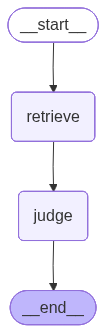

In [46]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

#### Compile

In [47]:
app = graph.compile()

In [49]:
import re

In [55]:
result = await app.ainvoke({
    "paper_text": makalah_text
})

DEBUG: [aquery_llm] Query param: QueryParam(mode='hybrid', only_need_context=False, only_need_prompt=False, response_type='Multiple Paragraphs', stream=False, top_k=40, chunk_top_k=20, max_entity_tokens=6000, max_relation_tokens=8000, max_total_tokens=30000, hl_keywords=[], ll_keywords=[], conversation_history=[], history_turns=0, model_func=None, user_prompt="\nAnda adalah asisten yang bertugas mengumpulkan konteks relevan untuk digunakan oleh LLM berikutnya\ndalam melakukan penilaian makalah seleksi kompetensi bidang untuk jabatan 'Ketua',  Ringkasan menyeluruh tentang:\n1. Deskripsi jabatan dan kompetensi yang diperlukan\n2. Kriteria penilaian makalah\n3. Rencana Strategis BPOM yang relevan untuk menilai kedalaman analisis\nBerikan jawaban dalam format paragraf, fokus pada poin-poin penting.\n", enable_rerank=True, include_references=False)
DEBUG: Flattened cache hit(key:hybrid:keywords:7f1b7a0d4d36fa148d0801d090ab8eec)
DEBUG: High-level keywords: ['Penilaian Penulisan Makalah', 'Ke


🔍 Stage 1: Retrieving assessment context for 'Ketua'...


DEBUG: Pre-computed 3 embeddings in single batch (purposes: query, ll, hl)
INFO: Query nodes: Ketua, Kesesuaian Isi, Sistematika Penulisan, Ketajaman Analisis, Penggunaan Bahasa, Bobot Penilaian, Struktur Makalah, Penilaian Kompetensi Teknis (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 138 relations
INFO: Query edges: Penilaian Penulisan Makalah, Kesesuaian Judul, Tema, Analisis, Format Penulisan (top_k:40, cosine:0.2)
INFO: Global query: 55 entites, 40 relations
INFO: Raw search results: 80 entities, 156 relations, 0 vector chunks
DEBUG: Before truncation: 80 entities, 156 relations
INFO: After truncation: 55 entities, 150 relations
DEBUG: Finding text chunks from 55 entities
DEBUG: Vector similarity chunk selection: num_of_chunks=137, entity_info_count=55
DEBUG: Vector similarity chunk selection: 63 unique chunk IDs collected
DEBUG: Using pre-computed query embedding for vector similarity chunk selection
DEBUG: Vector similarity chunk selection: 63 chunk vectors Retrieved
DE

✅ Context retrieved (2355 karakter)

📝 Stage 2: Evaluating paper...
✅ Evaluation complete (Score: 88.8)


In [56]:
from pprint import pprint

pprint(result)

{'assessment_context': 'Dalam konteks **Penilaian Penulisan Makalah** untuk '
                       'posisi Ketua, terdapat beberapa aspek penting yang '
                       'dinilai sebagai bagian dari evaluasi makalah. Berikut '
                       'adalah rincian mengenai penilaian tersebut:\n'
                       '\n'
                       '### 1. Kesesuaian Judul dengan Tema\n'
                       'Penilaian ini bertujuan untuk mengevaluasi seberapa '
                       'baik judul yang diajukan mencerminkan tema makalah. '
                       'Aspek ini akan dinilai berdasarkan daya tangkap dan '
                       'keselarasan antara perintah yang diberikan dengan '
                       'pelaksanaan tugas penulisan.\n'
                       '\n'
                       '### 2. Kesesuaian Isi Makalah dengan Judul dan Tema\n'
                       'Bagian ini menilai keselarasan antara isi makalah '
                       'dengan judul dan tema yang dit

### Conditional edges 

In [105]:
from typing import TypedDict, Dict, Any

class JudgeState(TypedDict):

    # input
    paper_text: str

    # retrieval
    assessment_context: str

    # faithfulness
    faithfulness_score: float

    # retry
    retrieval_retry_count: int

    # judge output
    evaluation_result: Dict[str, Any]

In [106]:
import random

async def retrieval_node(state: JudgeState):

    # simulasi retrieval
    context = f"Retrieved context version {random.randint(1,100)}"

    print("Retrieved Context:", context)

    state["assessment_context"] = context

    return state

In [107]:
async def faithfulness_node(state: JudgeState):

    # dummy faithfulness
    score = random.uniform(0.3, 1.0)

    print("Faithfulness Score:", score)

    state["faithfulness_score"] = float(score)

    return state

In [108]:
async def judge_node(state: JudgeState):

    context = state["assessment_context"]

    result = {
        "score": random.randint(70, 95),
        "context_used": context
    }

    print("Judge Result:", result)

    state["evaluation_result"] = result

    return state

In [109]:
from langgraph.graph import StateGraph, END

graph = StateGraph(JudgeState)

In [110]:
graph.add_node(
    "retrieve_context",
    retrieval_node
)

graph.add_node(
    "compute_faithfulness",
    faithfulness_node
)

graph.add_node(
    "evaluate_paper",
    judge_node
)

In [111]:
graph.set_entry_point("retrieve_context")

In [112]:
graph.add_edge(
    "retrieve_context",
    "compute_faithfulness"
)

In [113]:
graph.add_conditional_edges(
    "compute_faithfulness",
    route_after_faithfulness,
    {
        "retry": "retrieve_context",
        "continue": "evaluate_paper"
    }
)

In [114]:
def route_after_faithfulness(state):

    score = state["faithfulness_score"]

    retry_count = state.get(
        "retrieval_retry_count",
        0
    )

    if score < 0.7:

        if retry_count >= 2:
            return "continue"

        state["retrieval_retry_count"] = retry_count + 1

        return "retry"

    return "continue"

In [115]:
app = graph.compile()

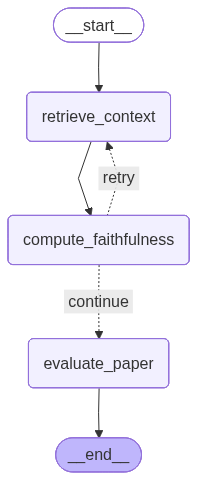

In [116]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [129]:
result = await app.ainvoke({

    "paper_text": "Penelitian tentang AI",

    "retrieval_retry_count": 0
})

Retrieved Context: Retrieved context version 54
Faithfulness Score: 0.8036933807855207
Judge Result: {'score': 75, 'context_used': 'Retrieved context version 54'}
